In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTENC

In [2]:
file_path = r"C:\Users\P1366370\Downloads\Base.csv"
df = pd.read_csv(file_path)

### Data Cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

In [4]:
df.isnull().sum().sum()

np.int64(0)

In [5]:
duplicated_rows = df[df.duplicated()]
print(f"Number of duplicated rows: {len(duplicated_rows)}")
display(duplicated_rows)

Number of duplicated rows: 0


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month


In [6]:
df.describe()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,...,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.0,1000000.000000
mean,0.011029,0.562696,0.493694,16.718568,86.587867,33.689080,1.025705e+00,8.661499,1572.692049,5665.296605,...,0.889676,10.839303,0.222988,515.851010,0.025242,7.544940,0.576947,1.018312,0.0,3.288674
std,0.104438,0.290343,0.289125,44.046230,88.406599,12.025799,5.381835e+00,20.236155,1005.374565,3009.380665,...,0.313293,12.116875,0.416251,487.559902,0.156859,8.033106,0.494044,0.180761,0.0,2.209994
min,0.000000,0.100000,0.000001,-1.000000,-1.000000,10.000000,4.036860e-09,-15.530555,1.000000,-170.603072,...,0.000000,-1.000000,0.000000,190.000000,0.000000,-1.000000,0.000000,-1.000000,0.0,0.000000
25%,0.000000,0.300000,0.225216,-1.000000,19.000000,20.000000,7.193246e-03,-1.181488,894.000000,3436.365848,...,1.000000,-1.000000,0.000000,200.000000,0.000000,3.103053,0.000000,1.000000,0.0,1.000000
50%,0.000000,0.600000,0.492153,-1.000000,52.000000,30.000000,1.517574e-02,-0.830507,1263.000000,5319.769349,...,1.000000,5.000000,0.000000,200.000000,0.000000,5.114321,1.000000,1.000000,0.0,3.000000
75%,0.000000,0.800000,0.755567,12.000000,130.000000,40.000000,2.633069e-02,4.984176,1944.000000,7680.717827,...,1.000000,25.000000,0.000000,500.000000,0.000000,8.866131,1.000000,1.000000,0.0,5.000000
max,1.000000,0.900000,0.999999,383.000000,428.000000,90.000000,7.845690e+01,112.956928,6700.000000,16715.565404,...,1.000000,32.000000,1.000000,2100.000000,1.000000,85.899143,1.000000,2.000000,0.0,7.000000


In [7]:
for column in df.columns:
    unique_count = df[column].nunique()
    print(f"Column: {column}, Unique values: {unique_count}")

Column: fraud_bool, Unique values: 2
Column: income, Unique values: 9
Column: name_email_similarity, Unique values: 998861
Column: prev_address_months_count, Unique values: 374
Column: current_address_months_count, Unique values: 423
Column: customer_age, Unique values: 9
Column: days_since_request, Unique values: 989330
Column: intended_balcon_amount, Unique values: 994971
Column: payment_type, Unique values: 5
Column: zip_count_4w, Unique values: 6306
Column: velocity_6h, Unique values: 998687
Column: velocity_24h, Unique values: 998940
Column: velocity_4w, Unique values: 998318
Column: bank_branch_count_8w, Unique values: 2326
Column: date_of_birth_distinct_emails_4w, Unique values: 40
Column: employment_status, Unique values: 7
Column: credit_risk_score, Unique values: 551
Column: email_is_free, Unique values: 2
Column: housing_status, Unique values: 7
Column: phone_home_valid, Unique values: 2
Column: phone_mobile_valid, Unique values: 2
Column: bank_months_count, Unique values: 3

### EDA

- **income (numeric)**: Annual income of the applicant (in decile form). Ranges between [0.1, 0.9].
- **name_email_similarity (numeric)**: Metric of similarity between email and applicant’s name. Higher values represent higher similarity. Ranges between [0, 1].
- **prev_address_months_count (numeric)**: Number of months in previous registered address of the applicant. Ranges between [−1, 380] months (-1 is a missing value).
- **current_address_months_count (numeric)**: Months in currently registered address of the applicant. Ranges between [−1, 429] months (-1 is a missing value).
- **customer_age (numeric)**: Applicant’s age in years, rounded to the decade. Ranges between [10, 90] years.
- **days_since_request (numeric)**: Number of days passed since application was done. Ranges between [0, 79] days.
- **intended_balcon_amount (numeric)**: Initial transferred amount for application. Ranges between [−16, 114] (negatives are missing values).
- **payment_type (categorical)**: Credit payment plan type. 5 possible (anonymized) values.
- **zip_count_4w (numeric)**: Number of applications within the same zip code in the last 4 weeks. Ranges between [1, 6830].
- **velocity_6h (numeric)**: Velocity of total applications made in the last 6 hours, i.e., average number of applications per hour in the last 6 hours. Ranges between [−175, 16818].
- **velocity_24h (numeric)**: Velocity of total applications made in the last 24 hours, i.e., average number of applications per hour in the last 24 hours. Ranges between [1297, 9586].
- **velocity_4w (numeric)**: Velocity of total applications made in the last 4 weeks, i.e., average number of applications per hour in the last 4 weeks. Ranges between [2825, 7020].
- **bank_branch_count_8w (numeric)**: Number of total applications in the selected bank branch in the last 8 weeks. Ranges between [0, 2404].
- **date_of_birth_distinct_emails_4w (numeric)**: Number of emails for applicants with the same date of birth in the last 4 weeks. Ranges between [0, 39].
- **employment_status (categorical)**: Employment status of the applicant. 7 possible (anonymized) values.
- **credit_risk_score (numeric)**: Internal score of application risk. Ranges between [−191, 389].
- **email_is_free (binary)**: Domain of application email (either free or paid).
- **housing_status (categorical)**: Current residential status for the applicant. 7 possible (anonymized) values.
- **phone_home_valid (binary)**: Validity of provided home phone.
- **phone_mobile_valid (binary)**: Validity of provided mobile phone.
- **bank_months_count (numeric)**: How old is the previous account (if held) in months. Ranges between [−1, 32] months (-1 is a missing value).
- **has_other_cards (binary)**: If the applicant has other cards from the same banking company.
- **proposed_credit_limit (numeric)**: Applicant’s proposed credit limit. Ranges between [200, 2000].
- **foreign_request (binary)**: If the origin country of request is different from the bank’s country.
- **source (categorical)**: Online source of application. Either browser (INTERNET) or app (TELEAPP).
- **session_length_in_minutes (numeric)**: Length of user session in banking website in minutes. Ranges between [−1, 107] minutes (-1 is a missing value).
- **device_os (categorical)**: Operating system of the device that made the request. Possible values are: Windows, macOS, Linux, X11, or other.
- **keep_alive_session (binary)**: User option on session logout.
- **device_distinct_emails (numeric)**: Number of distinct emails in banking website from the used device in the last 8 weeks. Ranges between [−1, 2] emails (-1 is a missing value).
- **device_fraud_count (numeric)**: Number of fraudulent applications with the used device. Ranges between [0, 1].
- **month (numeric)**: Month when the application was made. Ranges between [0, 7].
- **fraud_bool (binary)**: If the application is fraudulent or not.

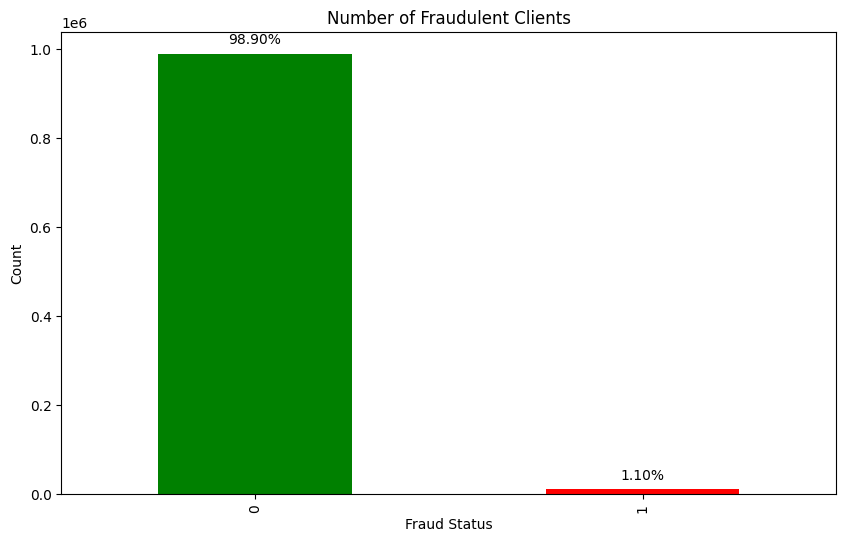

In [8]:
plt.figure(figsize=(10, 6))

# Count the occurrences of each fraud_status
fraud_counts = df['fraud_bool'].value_counts()

# Define colors based on the index
colors = ['green' if index == 0 else 'red' for index in fraud_counts.index]

# Create the bar plot
ax = fraud_counts.plot(kind='bar', color=colors)
plt.title('Number of Fraudulent Clients')
plt.xlabel('Fraud Status')
plt.ylabel('Count')

# Adding percentage on top of the bars
total = len(df)
for p in ax.patches:
    percentage = f'{(p.get_height() / total) * 100:.2f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

In [9]:
numerical_features = [
    "income", "name_email_similarity", "prev_address_months_count", 
    "current_address_months_count", "customer_age", "days_since_request", 
    "intended_balcon_amount", "zip_count_4w", "velocity_6h", "velocity_24h", 
    "velocity_4w", "bank_branch_count_8w", "date_of_birth_distinct_emails_4w", 
    "credit_risk_score", "bank_months_count", "proposed_credit_limit", 
    "session_length_in_minutes", "device_distinct_emails_8w", "device_fraud_count", "month"
]

categorical_features = [
    "payment_type", "employment_status", "housing_status", "source", "device_os",
    "email_is_free", "phone_home_valid", "phone_mobile_valid", 
    "has_other_cards", "foreign_request", "keep_alive_session"
]

target = "fraud_bool"

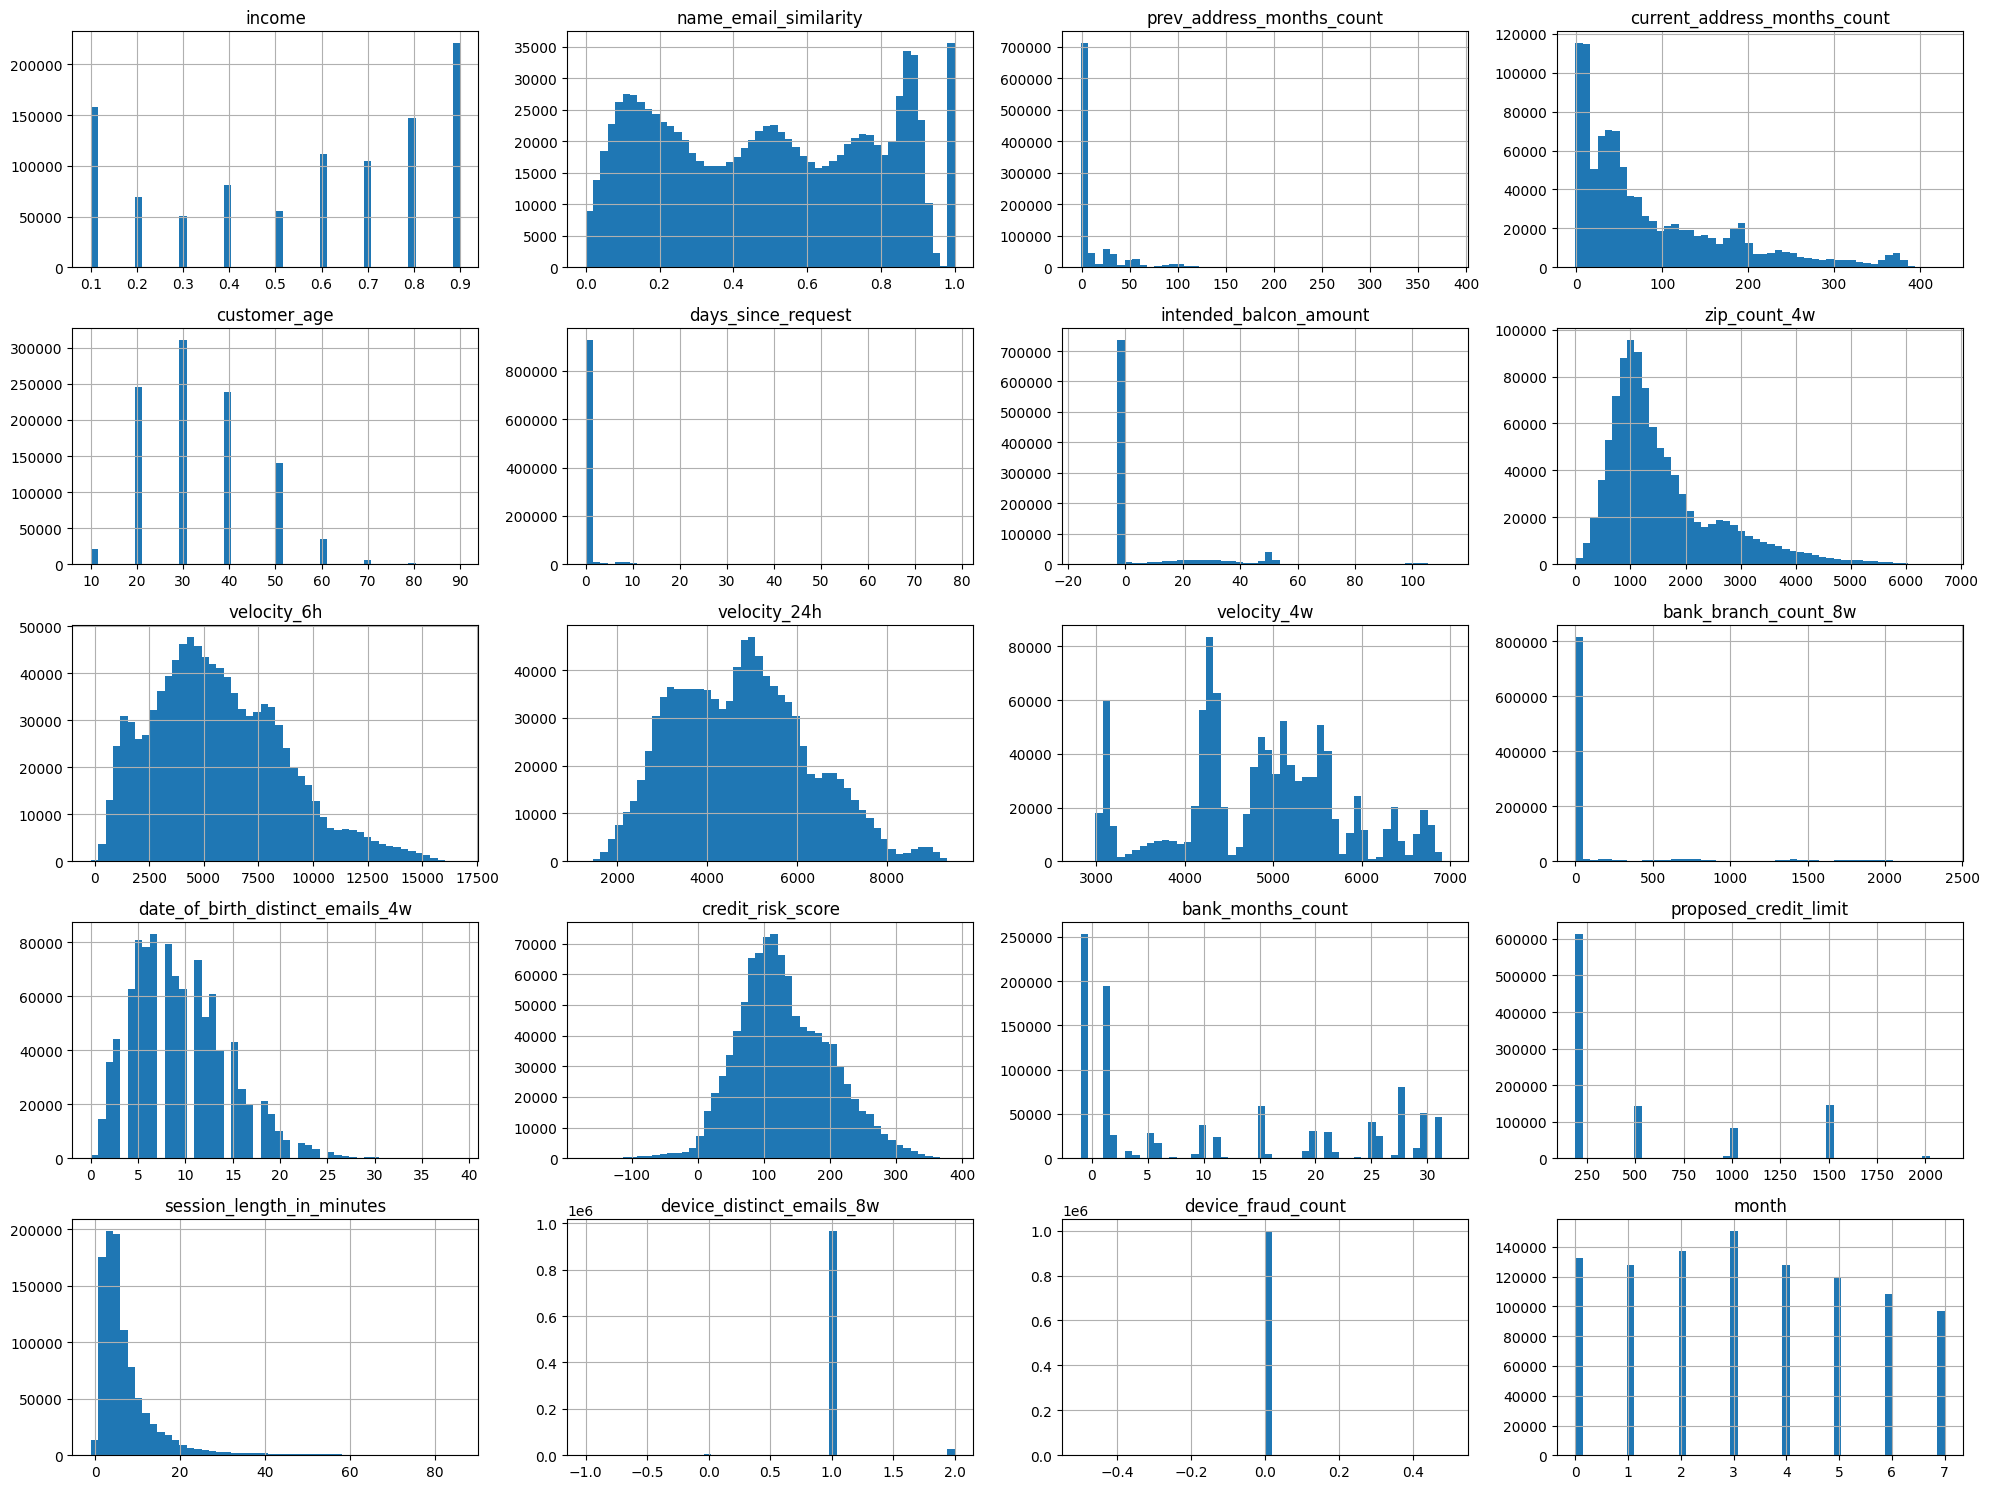

In [10]:
# Plot histograms for numerical columns
df[numerical_features].hist(bins=50, figsize=(20, 15))
plt.tight_layout()
plt.show()

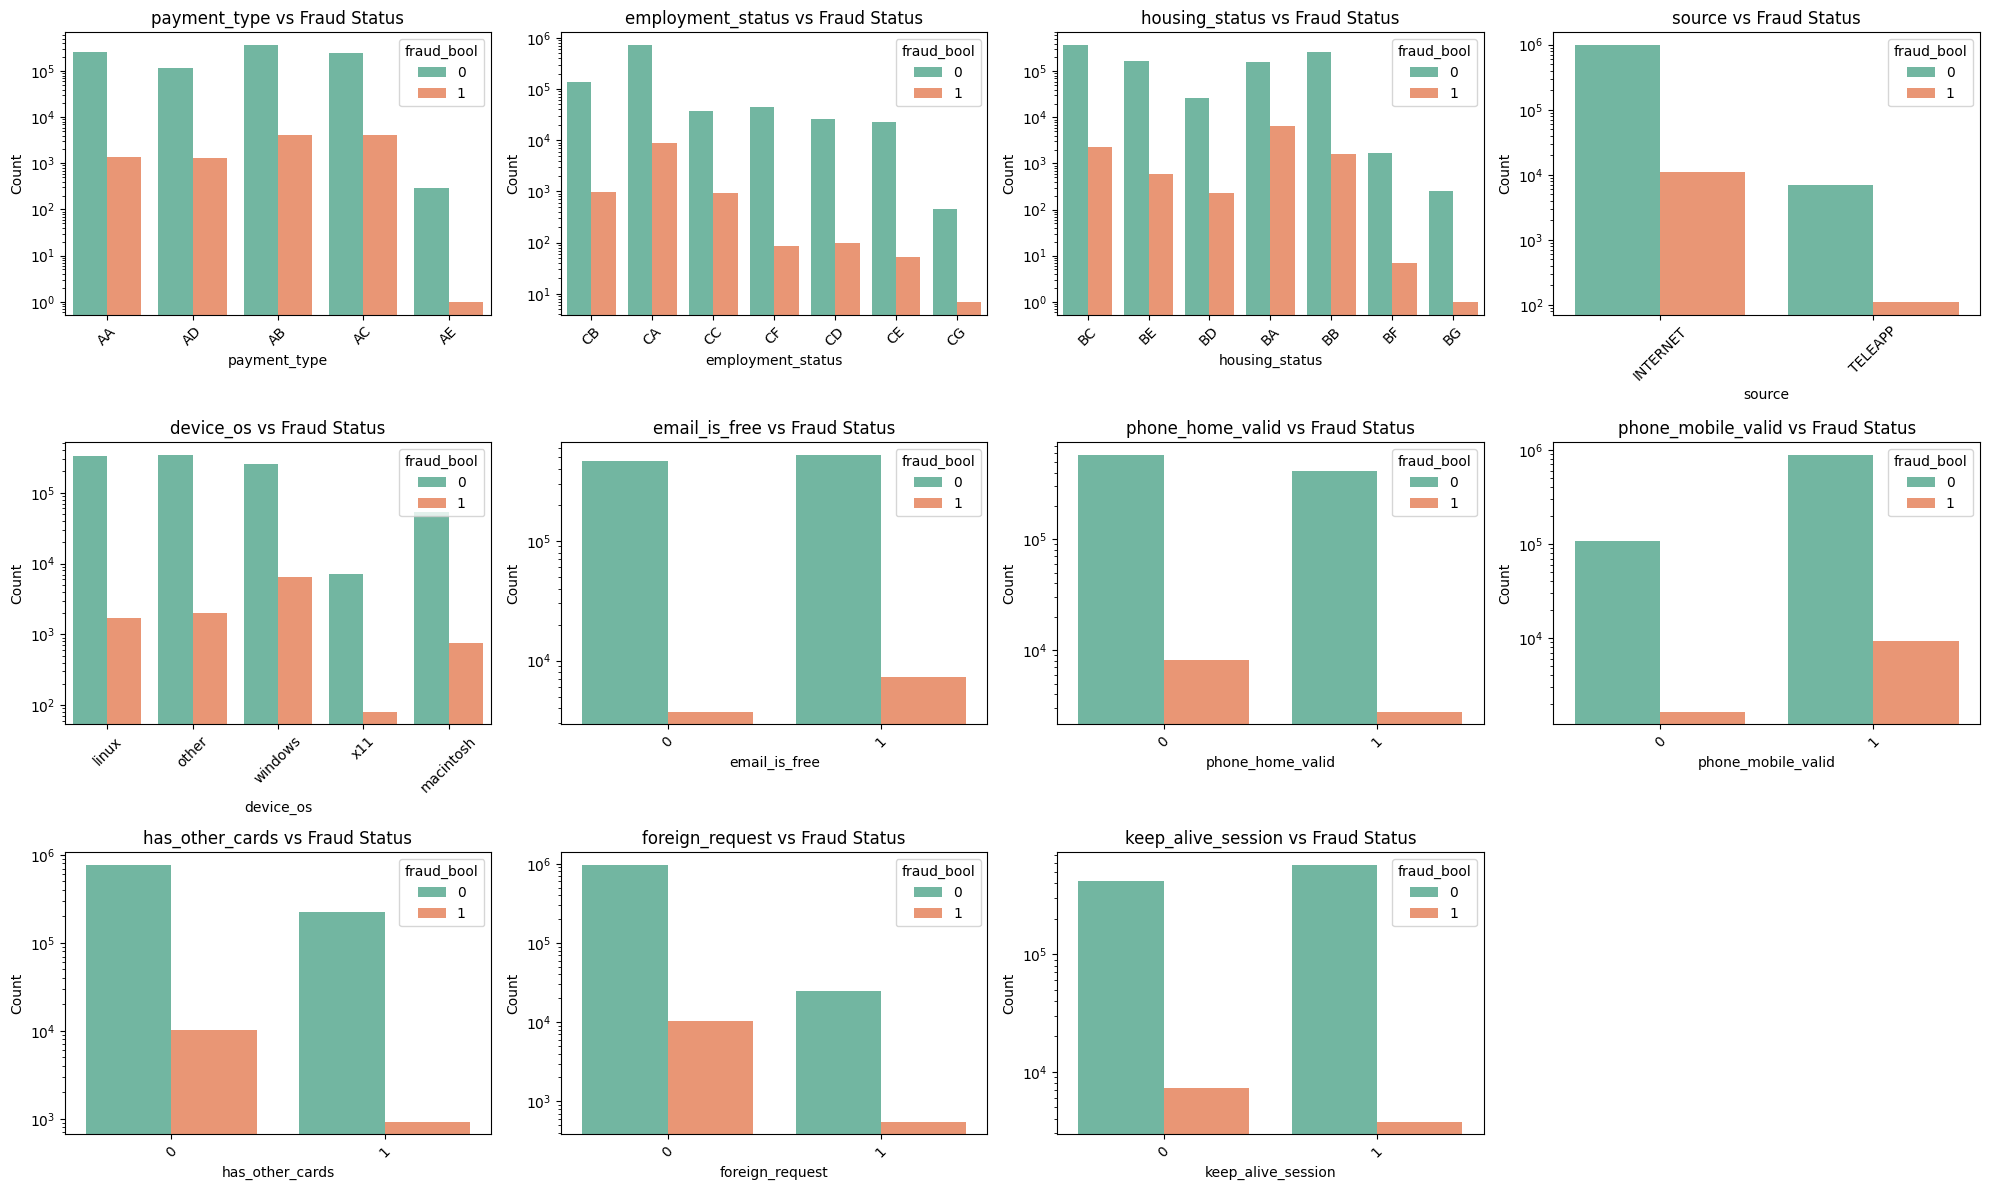

In [11]:
# Define rows and columns for the subplot grid (3 rows, 4 columns)
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 12))

# Flatten axes array for easier iteration
axes = axes.flatten()

# Plot categorical features with log scale for count axis
for i, feature in enumerate(categorical_features):
    sns.countplot(
        data=df,
        x=feature,
        hue="fraud_bool",
        palette="Set2",
        ax=axes[i]
    )
    axes[i].set_title(f"{feature} vs Fraud Status", fontsize=12)
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel("Count", fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_yscale('log')  # Apply log scale to the y-axis

# Hide any empty subplots (if less than 12 features)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

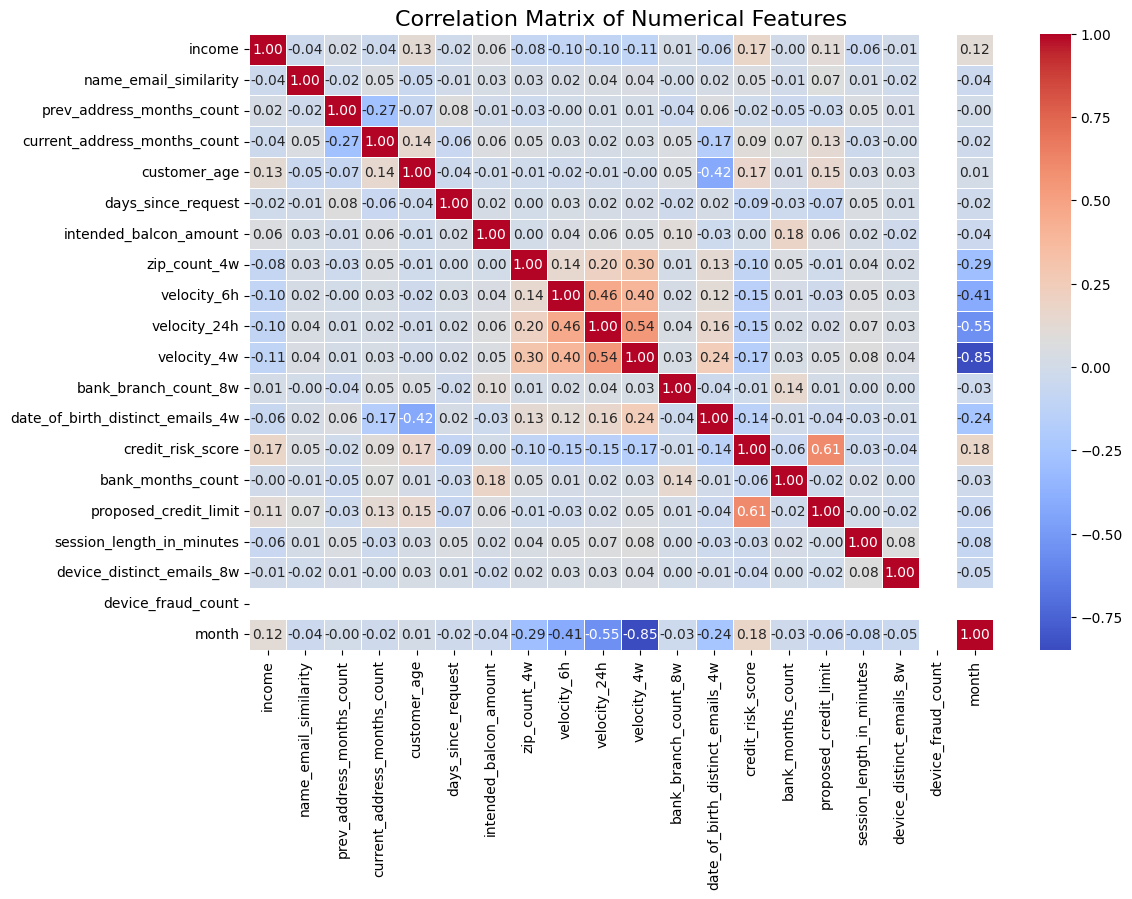

In [12]:
# Correlation matrix for numerical features
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_features].corr(), cmap="coolwarm", annot=True, fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features", fontsize=16)
plt.show()

### Feature Engineering

In [13]:
# 1. Velocity Ratio (example: velocity_6h / velocity_24h)
df['velocity_ratio'] = df['velocity_6h'] / df['velocity_24h']

# 2. Total Address Months (sum of previous and current address months)
df['total_address_months'] = df['prev_address_months_count'] + df['current_address_months_count']

# 3. Device Risk Score (example: device_fraud_count * device_distinct_emails_8w)
df['device_risk_score'] = df['device_fraud_count'] * df['device_distinct_emails_8w']

# 4. Income Bin (categorizing income into bins)
bins = [0, 30000, 70000, 150000, float('inf')]  # Define bins for income
labels = ['Low', 'Medium', 'High', 'Very High']
df['income_bin'] = pd.cut(df['income'], bins=bins, labels=labels, right=False)

# 5. Credit Risk Category (categorizing credit risk score into bins)
df['credit_risk_category'] = pd.cut(
    df['credit_risk_score'],
    bins=[0, 300, 600, 850],
    labels=['Low', 'Medium', 'High'],
    right=False
)

# View the first few rows of the dataframe to check the new features
df.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month,velocity_ratio,total_address_months,device_risk_score,income_bin,credit_risk_category
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,linux,1,1,0,0,1.668082,24,0,Low,Low
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,other,1,1,0,0,1.605375,88,0,Low,Low
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,windows,0,1,0,0,0.817157,23,0,Low,Low
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,linux,1,1,0,0,2.136382,25,0,Low,Low
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,other,0,1,0,0,1.483498,28,0,Low,Low


In [14]:
# Define training (first 6 months) and testing (last 2 months)
train_df = df[df["month"] <= 6]
test_df = df[df["month"] > 6]

# Define the target variable
target = "fraud_bool"

# Split into features (X) and target (y) for training data
X_train = train_df.drop(columns=[target])
y_train = train_df[target]

# Split into features (X) and target (y) for testing data
X_test = test_df.drop(columns=[target])
y_test = test_df[target]

# Print dataset shapes
print(f"Training Data: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Testing Data: X_test = {X_test.shape}, y_test = {y_test.shape}")

Training Data: X_train = (903157, 36), y_train = (903157,)
Testing Data: X_test = (96843, 36), y_test = (96843,)


In [15]:
# Encode categorical features (Label Encoding for binary, One-Hot Encoding for multi-class)
from sklearn.preprocessing import LabelEncoder

binary_features = [
    "source", "email_is_free", "phone_home_valid", "phone_mobile_valid", 
    "has_other_cards", "foreign_request", "keep_alive_session"
]

label_encoder = LabelEncoder()

for feature in binary_features:
    X_train[feature] = label_encoder.fit_transform(X_train[feature])
    X_test[feature] = label_encoder.transform(X_test[feature])  # Apply the same transformation on the test set

multi_class_features = [
    "payment_type", "employment_status", "housing_status", "device_os", 'income_bin', 'credit_risk_category'
]

X_train = pd.get_dummies(X_train, columns=multi_class_features, drop_first=True)
X_test = pd.get_dummies(X_test, columns=multi_class_features, drop_first=True)

In [18]:
numerical_fe_features = [
    "income", "name_email_similarity", "prev_address_months_count", 
    "current_address_months_count", "customer_age", "days_since_request", 
    "intended_balcon_amount", "zip_count_4w", "velocity_6h", "velocity_24h", 
    "velocity_4w", "bank_branch_count_8w", "date_of_birth_distinct_emails_4w", 
    "credit_risk_score", "bank_months_count", "proposed_credit_limit", 
    "session_length_in_minutes", "device_distinct_emails_8w", "device_fraud_count", "month", 
    "velocity_ratio", "total_address_months", "device_risk_score"
]

scaler = StandardScaler()

X_train[numerical_fe_features] = scaler.fit_transform(X_train[numerical_fe_features])
X_test[numerical_fe_features] = scaler.transform(X_test[numerical_fe_features])